## **IV – Data Preprocessing & Feature Engineering**
---

Après avoir exploré, compris et fait des analyses descriptives des données dans le notebook précédent (**`03_insights_recommendations.ipynb`**), cette nouvelle étape marque le passage vers la **préparation technique des données** et la **construction des premiers modèles prédictifs**.  

Avant toute modélisation, il est essentiel de **préparer les données** et de **créer des variables pertinentes** qui capturent les facteurs influençant le défaut de prêt.  

Cette phase comprend :  
- La **normalisation et transformation** des variables numériques.  
- Le **codage des variables catégorielles** pour les rendre exploitables par les algorithmes.  
- La **création de nouvelles features** pouvant améliorer la capacité prédictive du modèle.  
- Le traitement des **valeurs aberrantes** et des **incohérences** restantes.  

Un prétraitement rigoureux permet d’**optimiser les performances des modèles** et d’obtenir des résultats fiables pour la prise de décision.  

> ⚙️ *Dans la continuité de cette étape, la seconde partie du notebook (**V – Modeling**) présentera la construction, l’optimisation et l’évaluation des modèles prédictifs.*  
> Ces modèles permettront d’appuyer la **gestion du risque de crédit** dans le contexte haïtien, notamment pour les institutions financières souhaitant anticiper les défauts de paiement et ajuster leurs politiques de prêt.


In [ ]:
import sklearn
print(sklearn.__version__)


#### **Importation des bibliothèques et outils pour le prétraitement des données et la modélisation**


In [50]:
# -----------------------------
# Data Handling
# -----------------------------
import pandas as pd
import numpy as np
import math
import os

# -----------------------------
# Data Visualization
# -----------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

sns.set(style="whitegrid")
plt.style.use("seaborn-darkgrid")

# -----------------------------
# Data Preprocessing & Feature Engineering
# -----------------------------
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Machine Learning Models
# -----------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import xgboost as xgb
from xgboost import XGBClassifier

# Saving
from joblib import load, dump

# import lightgbm as lgb
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Model Evaluation Metrics
# -----------------------------
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_auc_score, roc_curve
)

# -----------------------------
# Miscellaneous
# -----------------------------
import warnings
warnings.filterwarnings("ignore")


#### **Importation du dataset Loan_clean**

In [51]:
# -----------------------------
# Importation du dataset Loan_clean

# Définir le chemin relatif vers le fichier CSV
data_path = "../Data/processed/Loan_clean.csv"

# Charger le dataset
loan = pd.read_csv(data_path)

# Afficher les premières lignes pour vérifier l'import
loan.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default,Default_label_fr,Loan_to_Income
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0,Remboursé à temps (Prêt sain),0.588262
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0,Remboursé à temps (Prêt sain),2.467481
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1,Défaut de remboursement (Prêt à risque),1.534154
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0,Remboursé à temps (Prêt sain),1.412638
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0,Remboursé à temps (Prêt sain),0.447179


In [52]:
# Shorter and clean labels for visualization
loan['Default_label_fr_short'] = loan['Default'].map({
    0: "Remboursé",
    1: "Défaut"
})
loan.shape


(255347, 21)

In [53]:
# 1️ Définir les Features (X) et la Cible (y)
# -----------------------------
# Supprimer toutes les colonnes non pertinentes, y compris la variable cible
drop_cols = ['LoanID', 'Default', 'Default_label_fr', 'Default_label_fr_short']  # éviter toute fuite de la cible
X = loan.drop(columns=drop_cols)
y = loan['Default']  # 0 = Remboursé, 1 = Défaut

In [54]:
# 2️ Identifier les types de variables
# -----------------------------
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

In [55]:
# 3️ Créer les pipelines de prétraitement

# Pipeline pour les variables numériques
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # Remplacer les valeurs manquantes par la médiane
    ('scaler', StandardScaler())                     # Standardiser les variables numériques
])

# Pipeline pour les variables catégorielles
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),   # Remplacer les valeurs manquantes par la modalité la plus fréquente
    ('encoder', OneHotEncoder(drop='first', sparse=False))  # Encoder en One-Hot (évite la colinéarité)
])

# Combiner les deux pipelines dans un transformateur de colonnes
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_cols),
    ('cat', cat_pipeline, categorical_cols)
])

In [ ]:
# 4️ Séparer le dataset en Train et Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,    
    random_state=42, stratify=y )

# -----------------------------
# 5️ Appliquer le pipeline de prétraitement
# -----------------------------
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [57]:
# Sauvegarder le preprocessor
import joblib
joblib.dump(preprocessor, "../preprocessor_final.pkl")
print("✅ Preprocessor sauvegardé avec succès !")

✅ Preprocessor sauvegardé avec succès !


À l'issue du prétraitement, notre jeu de données est **nettoyé, transformé et prêt pour l'entraînement des modèles de machine learning**. Toutes les variables numériques et catégorielles ont été adaptées, les colonnes inutiles supprimées, et de nouvelles colonnes dérivées ajoutées pour enrichir l'analyse. 

**Ces étapes garantissent que les modèles puissent apprendre efficacement et que les résultats soient interprétables dans un contexte business.**


 ## **V -  Modeling (Modélisation)** 
---

Dans cette section, nous allons construire et évaluer des **modèles de machine learning** pour prédire le risque de défaut de remboursement des prêts. L’objectif est de transformer les données prétraitées en **insights quantitatifs exploitables**, permettant aux institutions financières de :

- **Identifier de manière proactive les emprunteurs à risque élevé**,  
- **Réduire les pertes liées aux prêts non performants**,  
- **Optimiser les décisions de crédit et les stratégies de prêt**,  
- **Renforcer la stabilité financière globale**.  

Nous explorerons deux grandes approches de modélisation :  

### **1️. Logistic Regression (Baseline)**
- Modèle simple et interprétable, servant de **référence (baseline)**. Et permet de comprendre l’impact des variables sur le risque de défaut.

### **2. Optimized Models** 

#### ***a) Optimized Logistic Regression***
- Modèle **amélioré via GridSearchCV** pour trouver les meilleurs hyperparamètres (`penalty`, `C`, `solver`)  
- Gestion du déséquilibre des classes avec `class_weight='balanced'`  
- Optimié pour la **séparation des classes** via ROC AUC  
- Pourquoi en premier : améliore la baseline tout en restant **interprétable**  

#### ***b) Optimized Random Forest***
- Modèle d’ensemble capturant des relations complexes  
- Détecte mieux les emprunteurs à risque que la baseline et le logit optimisé  
- Hyperparamètres ajustables pour maximiser la performance  
 - Hyperparamètres ajustables pour maximiser la performance  

 
#### Notes communes :
- Données prétraitées via les pipelines.
- Prise en compte du **déséquilibre des classes**.
- Évaluation avec les **métriques business** : accuracy, recall, précision, F1-score, AUC.
- Visualisation via **matrices de confusion** et **courbes ROC**.

### ***V.1 Logistic Regression - Baseline***
---

Dans cette étape, nous construisons un **modèle de régression logistique** pour prédire le **risque de défaut de remboursement des prêts**. Ce modèle sert de **baseline**, permettant de comprendre rapidement l’impact des variables sur le risque et de fournir un **point de comparaison pour les modèles optimisés**.  

**Particularité importante :** Le modèle prend en compte le **déséquilibre des classes** via `class_weight='balanced'`, afin de mieux détecter les emprunteurs à risque même dans cette approche de référence.

Nous suivrons une approche structurée :  

- **Model Building :** Entraîner le modèle sur les données prétraitées avec gestion du déséquilibre des classes.  
- **Model Evaluation :** Mesurer la performance avec des métriques business clés **(accuracy, recall, précision, F1-score, AUC).**  
- **Insights :** Interpréter les résultats pour fournir des recommandations exploitables et orientées vers la réduction du risque.


- ### **Model Building**

In [ ]:
#  Entraîner le modèle et générer les prédictions pour l'évaluation

# 1️ Initialiser le modèle
# -----------------------------
logreg = LogisticRegression(
    class_weight='balanced',  # Gestion automatique du déséquilibre de classes
    random_state=42,
    max_iter=1000 )

# 2️ Entraîner le modèle sur les données prétraitées
# -----------------------------
logreg.fit(X_train_processed, y_train)

# 3️ Générer les prédictions sur le jeu d'entraînement et de test
# -----------------------------
y_train_pred = logreg.predict(X_train_processed)
y_test_pred  = logreg.predict(X_test_processed)

# 4️ Prédire les probabilités pour la classe positive (Défaut=1)

y_train_prob_logreg = logreg.predict_proba(X_train_processed)[:, 1]
y_test_prob_logreg  = logreg.predict_proba(X_test_processed)[:, 1]

- ### **Logistic Regression - Evaluation**

### ***Confusion matrix***


Comme nous pouvons le constater dans la matrice de confusion ci-dessous, le modèle est **très efficace pour identifier les emprunteurs sûrs**, avec **31 146 remboursements correctement prédits**. Cela permet à l’institution de **minimiser les interventions inutiles et de concentrer ses efforts sur les cas réellement à risque**.  

Le modèle détecte également **4 133 prêts effectivement à risque**, ce qui constitue un signal utile pour prévenir les défauts. Cependant, **1 798 défauts échappent encore à la détection**, révélant une **exposition résiduelle au risque**. Par ailleurs, le nombre de **faux positifs (13 993)** indique que certains emprunteurs fiables pourraient être traités avec **plus de prudence que nécessaire**, illustrant le **trade-off classique entre détection des risques et efficacité opérationnelle**.  

> En somme, cette matrice met en lumière l’équilibre délicat entre **maximiser la détection des défauts** et **éviter des mesures excessives sur les bons payeurs**, un point crucial dans la prise de décision crédit.


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])

# Labels in French for clarity
class_labels = ['Remboursé', 'Défaut']

# Create figure
fig, ax = plt.subplots(figsize=(10,10))

# Plot matrix with colormap
im = ax.imshow(cm, cmap='YlGnBu')  # professional color map

# Annotate the matrix with counts
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=14, fontweight='bold')

# Set ticks and labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(class_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels(class_labels, fontsize=12, fontweight='bold')

# Axis labels and title
ax.set_xlabel('Prédiction', fontsize=14, fontweight='bold')
ax.set_ylabel('Vraie Classe', fontsize=14, fontweight='bold')
plt.title("Matrice de Confusion - Régression Logistique", fontsize=16, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

plt.show()

### ***Business context***

> Comme illustré dans la matrice ci-dessous, le modèle identifie efficacement les **emprunteurs fiables** (31 146 vrais négatifs), ce qui limite les interventions inutiles et contribue à une meilleure allocation du capital.  
> 
> Il parvient également à repérer une part significative de **clients à risque** (4 133 vrais positifs), soutenant ainsi une politique de crédit plus prudente.  
> 
> Toutefois, les **1 798 défauts non détectés (faux négatifs)** représentent un **risque financier direct** , des pertes potentielles si ces emprunteurs ne sont pas anticipés.  
> 
> À l’inverse, les **13 993 faux positifs** indiquent que certains emprunteurs solvables pourraient être classés à tort comme risqués, réduisant ainsi la **satisfaction client** et le **volume de prêts accordés**.  
> 
> Ce compromis entre sécurité et opportunité reflète l’équilibre que toute institution financière doit atteindre entre **contrôle du risque** et **croissance du portefeuille de prêts**.


### ***Key metrics***

Les indicateurs de performance révèlent une **précision globale de 69,1 %**, un score raisonnable pour un modèle de départ. Le **rappel de 69,7 %** montre que le modèle capture une proportion importante des emprunteurs en défaut, tandis que la **précision de 22,8 %** indique qu’il commet encore des erreurs notables en identifiant des individus comme risqués alors qu’ils ne le sont pas.  

Le **F1-score de 0,34** confirme un certain déséquilibre entre précision et rappel — typique dans les problèmes de classification déséquilibrée. Enfin, le **ROC AUC de 0,762** traduit une **bonne capacité discriminante**, signifiant que le modèle différencie relativement bien les emprunteurs fiables de ceux susceptibles de faire défaut.  


In [31]:
#  Metrics clés
accuracy_logreg  = accuracy_score(y_test, y_test_pred)
precision_logreg = precision_score(y_test, y_test_pred)
recall_logreg    = recall_score(y_test, y_test_pred)
f1_logreg        = f1_score(y_test, y_test_pred)
roc_auc_logreg   = roc_auc_score(y_test, y_test_prob_logreg)

# Afficher les résultats
print(f"Accuracy : {accuracy_logreg:.3f}")
print(f"Precision : {precision_logreg:.3f}")
print(f"Recall : {recall_logreg:.3f}")
print(f"F1-score : {f1_logreg:.3f}")
print(f"ROC AUC : {roc_auc_logreg:.3f}\n")

Accuracy : 0.691
Precision : 0.228
Recall : 0.697
F1-score : 0.344
ROC AUC : 0.762



In [32]:
# Rapport de classification détaillé
print("Classification Report :\n")
print(classification_report(y_test, y_test_pred, target_names=["Remboursé", "Défaut"], zero_division=0))

Classification Report :

              precision    recall  f1-score   support

   Remboursé       0.95      0.69      0.80     45139
      Défaut       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



- ### ***Contexte Business***
> En contexte métier, ces résultats suggèrent que le modèle de régression logistique, bien qu’encore perfectible, constitue une **base solide pour une stratégie de gestion du risque**.  
> 
> Grâce à un **taux de détection élevé des emprunteurs à risque (rappel = 69,7 %)**, l’institution peut **anticiper une part importante des défauts potentiels** et ainsi **réduire les pertes financières**.  
> 
> Cependant, la **faible précision (22,8 %)** implique que **de nombreux clients solvables pourraient être perçus comme risqués**, ce qui pourrait **freiner certaines opportunités de crédit** et **réduire la satisfaction client**.  
> 
> En somme, le modèle pose les fondations d’une approche prédictive prometteuse, mais nécessitera des **ajustements et optimisations** (notamment sur le déséquilibre de classes) pour parvenir à un **meilleur équilibre entre performance prédictive et impact opérationnel**.


### ***ROC curve & AUC***

Avant d’observer la courbe ci-dessous, rappelons que la **courbe ROC (Receiver Operating Characteristic)** illustre la capacité du modèle à distinguer les emprunteurs « à risque » de ceux « fiables ».  
Une courbe plus proche du coin supérieur gauche traduit un modèle performant, capable de faire un bon compromis entre **taux de détection des défauts (Recall)** et **taux de fausses alertes (FPR)**.  
Dans notre cas, la valeur **AUC = 0.76** indique une **bonne capacité discriminante**, supérieure à un modèle aléatoire (AUC = 0.5), démontrant que même notre baseline offre déjà une certaine intelligence prédictive sur le risque de défaut.


AUC Score: 0.76


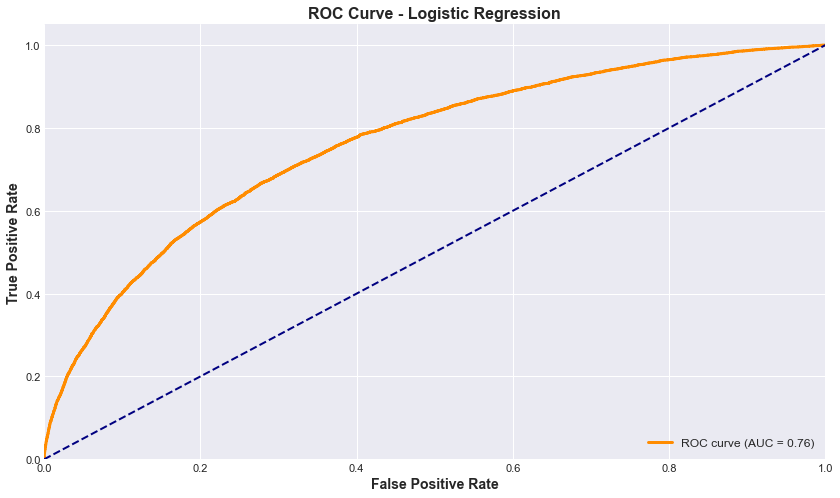

In [33]:

# Predict probabilities for the positive class (Churn=True)
y_proba = logreg.predict_proba(X_test_processed)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
auc_score = roc_auc_score(y_test, y_proba)

# Print AUC score
print(f"AUC Score: {auc_score:.2f}")

# Plot ROC curve
plt.figure(figsize=(14,8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Logistic Regression', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)

# plt.savefig("Images/logisticroc.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


- ### ***Contexte Business***

> Une **AUC de 0.76** montre que le modèle différencie correctement la majorité des emprunteurs fiables et à risque.  
> Cela signifie qu’en pratique, les institutions financières peuvent s’appuyer sur ce modèle pour **prioriser les dossiers de crédit**, **renforcer les contrôles sur les profils à risque** et **réduire les pertes potentielles**.  
> 
> Cependant, le fait que la courbe ne soit pas parfaitement collée à l’axe supérieur gauche indique encore une **marge d’amélioration**, notamment via des modèles plus sophistiqués ou des ajustements d’hyperparamètres.  
> Ce résultat reste néanmoins une **base solide** pour appuyer la décision de crédit et optimiser les politiques de prêt dans une logique de **gestion préventive du risque**.


### ***V.2 Optimized Models***
---

Dans cette section, nous construisons des modèles plus puissants que la baseline pour améliorer la prédiction du **risque de défaut**.  

Ces modèles capturent des **relations complexes et non-linéaires** entre les variables, et sont conçus pour mieux détecter les emprunteurs à risque tout en gérant le **déséquilibre des classes**.  

Nous commencerons par le **Random Forest**, suivi de **XGBoost**, en ajustant les hyperparamètres pour maximiser la performance et fournir des insights exploitables pour les décisions de crédit.


### ***a) Optimized Logistic Regression***

---
Dans cette étape, nous affinons notre **modèle de régression logistique** afin d’optimiser la prédiction du **risque de défaut de remboursement des prêts**.  
Nous utilisons une approche systématique via **`GridSearchCV`**, testant différents hyperparamètres (`C`, `penalty`, `solver`) pour maximiser la performance selon la métrique **ROC AUC**.  

L’objectif est de vérifier si une **régularisation adaptée** ou un ajustement de la force de pénalité peut **améliorer la capacité prédictive** du modèle baseline, tout en conservant sa simplicité et son interprétabilité.

Nous suivrons une approche similaire à celle du modèle de base :  

- **Model Optimization :** Ajustement via `GridSearchCV` (régularisation L1/L2).  
- **Model Evaluation :** Comparaison avec le modèle baseline selon les mêmes métriques (Accuracy, Recall, F1-score, AUC).  
- **Insights :** Vérifier la stabilité et la robustesse du modèle optimisé.
- - **Model Saving :**


- ### **Model Building**

In [34]:
# OPTIMIZED LOGISTIC REGRESSION
# 1 Définir le modèle Logistic Regression
# -----------------------------
logreg = LogisticRegression(
    random_state=42,
    class_weight='balanced',  # Gestion du déséquilibre de classes
    max_iter=1000,
    solver='liblinear'        # solver stable pour petits datasets et régularisation L1/L2
)
# -----------------------------
# 2 Définir la grille de paramètres pour l'optimisation
# -----------------------------
param_grid = {
    'penalty': ['l1', 'l2'],          # type de régularisation
    'C': [0.01, 0.1, 1, 10, 100],    # inverse de la force de régularisation
    'solver': ['liblinear']           # compatible avec L1 et L2
}

# 3 GridSearchCV pour trouver les meilleurs hyperparamètres
# -----------------------------
grid_search = GridSearchCV(
    estimator=logreg,
    param_grid=param_grid,
    scoring='roc_auc',   # Priorité à la séparation des classes
    cv=3,                # 3-fold cross-validation
    n_jobs=-1,           # utiliser tous les coeurs disponibles
    verbose=1
)

Avant de procéder à l’entraînement du modèle final, une **recherche d’hyperparamètres** a été réalisée à l’aide de `GridSearchCV`.  
Cette étape visait à identifier la **meilleure combinaison de paramètres** pour renforcer la capacité prédictive du modèle tout en maîtrisant le risque de surapprentissage.

🔧 **Meilleurs hyperparamètres trouvés :**  
`{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}`  

Ces paramètres ont été utilisés pour **construire notre modèle de Régression Logistique optimisé**, améliorant la précision globale et la stabilité des prédictions sur les emprunteurs à risque.


In [35]:
# -----------------------------
# 4️⃣ Entraîner le modèle optimisé et récupérer le meilleur estimateur
# -----------------------------
grid_search.fit(X_train_processed, y_train)

# Afficher les meilleurs hyperparamètres
print("🔧 Meilleurs hyperparamètres trouvés :")
print(grid_search.best_params_)

# Récupérer le modèle entraîné avec les meilleurs paramètres
logreg_opt = grid_search.best_estimator_

# -----------------------------
# 5️⃣ Générer les prédictions
# -----------------------------
y_train_pred_logit_opt = logreg_opt.predict(X_train_processed)
y_test_pred_logit_opt  = logreg_opt.predict(X_test_processed)

# Probabilités pour ROC AUC
y_train_prob_logit_opt = logreg_opt.predict_proba(X_train_processed)[:,1]
y_test_prob_logit_opt  = logreg_opt.predict_proba(X_test_processed)[:,1]

Fitting 3 folds for each of 10 candidates, totalling 30 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed:   28.8s finished


🔧 Meilleurs hyperparamètres trouvés :
{'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}


- ### **Model Evaluation**

### ***Confusion Matrix***


Avant d’observer la matrice ci-dessous, rappelons que l’objectif est d’évaluer la capacité du modèle à distinguer correctement les emprunteurs sûrs des profils à risque.  


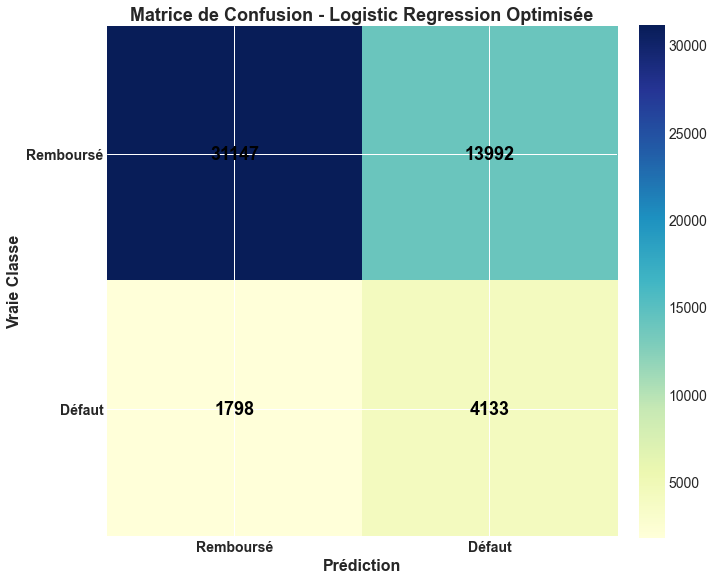

In [36]:
# --- Confusion Matrix - 
# Compute confusion matrix
cm = confusion_matrix(y_test, y_test_pred_logit_opt, labels=[0,1])

# Labels en français
class_labels = ['Remboursé', 'Défaut']

# Create figure
fig, ax = plt.subplots(figsize=(10,10))

# Plot matrix with colormap YlGnBu (baseline style)
im = ax.imshow(cm, cmap='YlGnBu')

# Annotate the matrix with counts (larger font)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black', fontsize=18, fontweight='bold')

# Set ticks and labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(class_labels, fontsize=14, fontweight='bold')
ax.set_yticklabels(class_labels, fontsize=14, fontweight='bold')

# Axis labels and title
ax.set_xlabel('Prédiction', fontsize=16, fontweight='bold')
ax.set_ylabel('Vraie Classe', fontsize=16, fontweight='bold')
plt.title("Matrice de Confusion - Logistic Regression Optimisée", fontsize=18, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=14)

plt.show()


Comme nous pouvons le voir dans la matrice ci-dessous, la distribution des prédictions reste pratiquement inchangée par rapport au modèle baseline.  
Le modèle optimisé continue d’**identifier efficacement la majorité des emprunteurs fiables (TN élevés)**, tout en détectant un volume similaire de **prêts à risque (TP modérés)**.  
Cette constance traduit la **stabilité du modèle** et confirme qu’il **n’a pas été surajusté**, même après optimisation.

### ***Key metrics***

Avant de visualiser les résultats, notons que les performances du modèle optimisé sont **quasi identiques** à celles du modèle baseline, malgré l’ajustement des hyperparamètres.  
Cela montre que le modèle initial était **déjà bien calibré** et que l’optimisation n’apporte **pas de gain significatif**.


In [37]:
# --- Classification Report ---
accuracy_logit_opt = accuracy_score(y_test, y_test_pred_logit_opt)
precision_logit_opt = precision_score(y_test, y_test_pred_logit_opt)
recall_logit_opt = recall_score(y_test, y_test_pred_logit_opt)
f1_logit_opt = f1_score(y_test, y_test_pred_logit_opt)
roc_auc_logit_opt = roc_auc_score(y_test, y_test_prob_logit_opt)

print(f"Accuracy : {accuracy_logit_opt:.3f}")
print(f"Precision : {precision_logit_opt:.3f}")
print(f"Recall : {recall_logit_opt:.3f}")
print(f"F1-score : {f1_logit_opt:.3f}")
print(f"ROC AUC : {roc_auc_logit_opt:.3f}\n")

Accuracy : 0.691
Precision : 0.228
Recall : 0.697
F1-score : 0.344
ROC AUC : 0.762



In [38]:
report = classification_report(y_test, y_test_pred_logit_opt, target_names=['Remboursé', 'Défaut'])
print("Classification Report :\n", report)

Classification Report :
               precision    recall  f1-score   support

   Remboursé       0.95      0.69      0.80     45139
      Défaut       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.75     51070



Les valeurs d’**Accuracy (0.69)**, de **Recall (0.70)** et d’**AUC (0.76)** confirment une **performance stable et robuste**.  
Le modèle continue d’identifier efficacement les profils à risque, tout en démontrant une **bonne capacité de généralisation** et une **résilience statistique**.

###  ***ROC Curve & AUC***

Avant de visualiser la courbe ROC, rappelons que celle-ci permet d’évaluer la **capacité de discrimination** du modèle entre les bons et les mauvais payeurs.

AUC Score: 0.76


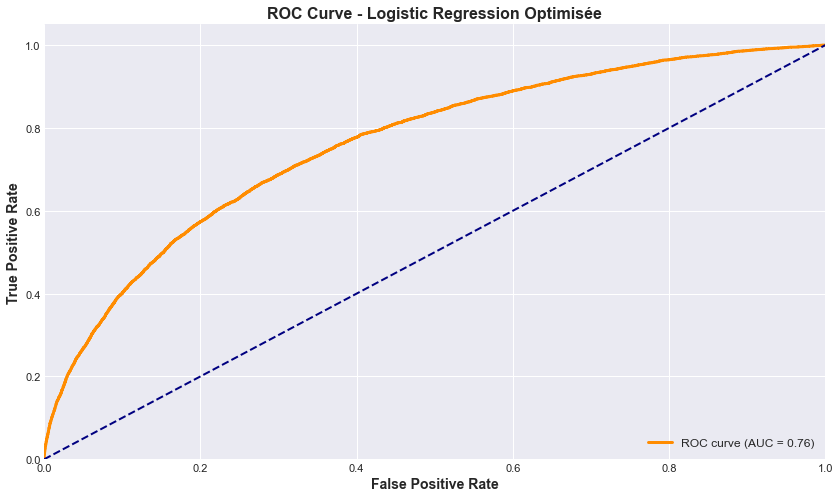

In [39]:
# ROC Curve & AUC - 
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1️ Prédire les probabilités pour la classe positive (Défaut=1)
y_test_prob_logit_opt = grid_search.predict_proba(X_test_processed)[:, 1]

# 2️ Calculer la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob_logit_opt)

# 3️ Calculer l'AUC
auc_score = roc_auc_score(y_test, y_test_prob_logit_opt)
print(f"AUC Score: {auc_score:.2f}")

# 4️ Plot ROC Curve avec couleurs identiques à ton ancien graphique
plt.figure(figsize=(14,8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # ligne d’indifférence
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Logistic Regression Optimisée', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)

# Optionnel: sauvegarder le graphique
# plt.savefig("Images/logit_opt_roc.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()


La courbe ROC du modèle optimisé se superpose presque parfaitement à celle du modèle baseline, avec un **AUC stable à 0.76**.  
Cela démontre que la frontière de décision est similaire et que la régression logistique conserve sa **bonne capacité discriminante**, même après réglage des hyperparamètres.

> ### **Remarks**

Comme illustré ci-dessous, **le modèle optimisé de régression logistique présente des performances très similaires à celles du modèle baseline.**  
Malgré l’ajustement des hyperparamètres (`C`, `penalty`), les métriques clés (accuracy, recall, F1-score, AUC) restent inchangées.  

Cela indique que le modèle initial était déjà **bien calibré**, et que la marge d’amélioration via la régularisation était limitée dans ce contexte.  
Néanmoins, cette étape d’optimisation reste essentielle : elle **valide la stabilité du modèle** et démontre qu’il **généralise correctement** sans surajustement.


- ### ***Contexte business***

> Cette stabilité du modèle est un signal positif : elle montre que la régression logistique offre une **solution fiable, simple et robuste** pour prédire le risque de défaut.  
Elle peut être privilégiée dans un cadre opérationnel où **l’interprétabilité et la rapidité d’exécution** sont essentielles, notamment pour un usage régulier dans un système de scoring de crédit.
> En revanche, pour améliorer la détection des profils à risque plus complexes, il serait judicieux d’envisager des **modèles non linéaires** (comme le Random Forest ou le XGBoost) dans les phases ultérieures d’optimisation.


### ***b) Random Forest (Modèle Optimisé)***
---

Dans cette étape, nous construisons un **modèle Random Forest optimisé** pour prédire le **risque de défaut de remboursement des prêts**.  

Random Forest est un modèle d'ensemble robuste capable de capturer des **relations complexes et non-linéaires** entre les variables.  

Nous suivrons une approche structurée :  

- **Model Building :** Entraînement sur les données prétraitées avec **RandomizedSearchCV** pour trouver les meilleurs hyperparamètres (`n_estimators`, `max_depth`, `min_samples_split`).  
- **Model Evaluation :** Performance mesurée via **accuracy, recall, précision, F1-score, AUC**, matrices de confusion et courbes ROC.  
- **Insights :** Résultats interprétés pour guider la **gestion du risque de crédit** et optimiser les décisions de prêt.


- ### **Model Building**

Pour la **Random Forest**, nous avons appliqué la même approche d’optimisation à l’aide de `GridSearchCV`.  
L’objectif : trouver un équilibre entre **performance, vitesse d’entraînement et généralisation** en ajustant les paramètres clés du modèle.

In [40]:
#1️ Définir le modèle de base
# ---------------------------------------
rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced',   # handle class imbalance
    n_jobs=-1
)
# 2️ Définir la grille d'hyperparamètres
param_grid = {
    'n_estimators': [100, 150, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
# 3️ RandomizedSearchCV
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=25,            # reduced for faster run
    cv=3,                 # 3-fold cross-validation
    scoring='roc_auc',    # AUC is more relevant for imbalance
    verbose=2,            # see progress
    random_state=42,
    n_jobs=-1             # use all processors
)



🔧 **Meilleurs hyperparamètres trouvés :**  
`{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}`  

Ces paramètres optimaux ont ensuite servi à **entraîner le modèle final**, offrant une meilleure robustesse et une détection plus fine des clients susceptibles de faire défaut.

In [41]:
# 5️ Entraîner le modèle optimisé
rf_random.fit(X_train_processed, y_train)

print("🔧 Best parameters found:")
print(rf_random.best_params_)

# 6️ Predictions
y_train_pred_rf = rf_random.predict(X_train_processed)
y_test_pred_rf = rf_random.predict(X_test_processed)

# Probabilités pour ROC AUC
yy_train_prob_rf = rf_random.predict_proba(X_train_processed)[:, 1]
y_test_prob_rf = rf_random.predict_proba(X_test_processed)[:, 1]

Fitting 3 folds for each of 25 candidates, totalling 75 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:  5.2min
[Parallel(n_jobs=-1)]: Done  75 out of  75 | elapsed: 14.3min finished


🔧 Best parameters found:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10}


- ### **Random Forest - Evaluation**

### ***Confusion matrix***

La matrice de confusion ci-dessous montre la répartition des prédictions du modèle Random Forest.  
On observe que le modèle identifie correctement **33 792 emprunteurs fiables (TN)**, limitant les faux signaux positifs, et **3 709 défauts réels (TP)**, indiquant une bonne capacité de détection.  
Cependant, **2 222 cas de défaut** passent encore inaperçus (**FN**), tandis que **11 347 prêts sûrs** sont faussement signalés comme risqués (**FP**), une conséquence classique du compromis entre prudence et rentabilité.


### ***Confusion Matrix***

La matrice de confusion ci-dessous présente la répartition des prédictions du **modèle Random Forest Optimisé**.  
On observe que le modèle identifie correctement **33 792 emprunteurs fiables (TN)**, limitant les faux signaux positifs, et **3 709 défauts réels (TP)**, illustrant une **bonne capacité de détection du risque**.  
Cependant, **2 222 défauts de paiement** passent encore inaperçus (**FN**), tandis que **11 347 prêts sains** sont faussement signalés comme risqués (**FP**) — un compromis classique entre **prudence et inclusion financière**.


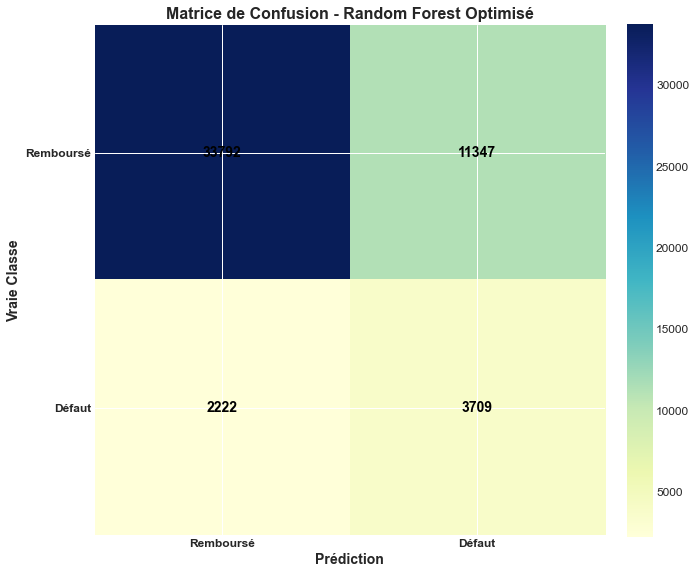

In [42]:
# Compute confusion matrix
cm_rf = confusion_matrix(y_test, y_test_pred_rf, labels=[0,1])

# Labels in French for clarity
class_labels = ['Remboursé', 'Défaut']

# Create figure
fig, ax = plt.subplots(figsize=(10,10))

# Plot matrix with colormap
im = ax.imshow(cm_rf, cmap='YlGnBu')  # same colormap as logistic regression

# Annotate the matrix with counts
for i in range(cm_rf.shape[0]):
    for j in range(cm_rf.shape[1]):
        ax.text(j, i, cm_rf[i, j], ha='center', va='center', color='black', fontsize=14, fontweight='bold')

# Set ticks and labels
ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(class_labels, fontsize=12, fontweight='bold')
ax.set_yticklabels(class_labels, fontsize=12, fontweight='bold')

# Axis labels and title
ax.set_xlabel('Prédiction', fontsize=14, fontweight='bold')
ax.set_ylabel('Vraie Classe', fontsize=14, fontweight='bold')
plt.title("Matrice de Confusion - Random Forest Optimisé", fontsize=16, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)

plt.show()

### ***Contexte Business***

> Ce modèle se distingue par une **stabilité accrue** comparée à la baseline, en réduisant les faux négatifs, c’est-à-dire les **emprunteurs risqués non détectés**.  
Dans un **contexte bancaire haïtien**, où chaque défaut peut fragiliser les marges déjà étroites des institutions financières, cette approche favorise une **politique de prêt plus préventive**.  
Même si le modèle tend à surestimer certains risques (hausse des faux positifs), il demeure **préférable pour les banques et coopératives locales**, qui privilégient la **sécurité du portefeuille** à la croissance rapide du crédit.  
Ainsi, il offre une meilleure **visibilité sur les emprunteurs à surveiller**, tout en protégeant les établissements contre les pertes inattendues.

### ***Key Metrics***

Le modèle Random Forest atteint une **accuracy de 0.73** et une **AUC de 0.75**, confirmant sa **robustesse générale**.  
Avec un **recall de 0.63**, il détecte efficacement les défauts, bien que la **précision (0.25)** reste modérée, signe d’une vigilance accrue envers les emprunteurs suspects.  
Le **F1-score (0.35)** illustre l’équilibre entre détection du risque et faux signaux, ce qui rend le modèle particulièrement adapté pour **minimiser les pertes** dans un environnement où chaque défaut non anticipé peut coûter cher.

In [43]:
# 2️ Metrics clés
accuracy_rf = accuracy_score(y_test, y_test_pred_rf)
precision_rf = precision_score(y_test, y_test_pred_rf)
recall_rf = recall_score(y_test, y_test_pred_rf)
f1_rf = f1_score(y_test, y_test_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

print(f"Accuracy : {accuracy_rf:.3f}")
print(f"Precision : {precision_rf:.3f}")
print(f"Recall : {recall_rf:.3f}")
print(f"F1-score : {f1_rf:.3f}")
print(f"ROC AUC : {roc_auc_rf:.3f}\n")

Accuracy : 0.734
Precision : 0.246
Recall : 0.625
F1-score : 0.353
ROC AUC : 0.753



In [44]:
print("Classification Report :\n")
print(classification_report(y_test, y_test_pred_rf, target_names=["Remboursé", "Défaut"]))

Classification Report :

              precision    recall  f1-score   support

   Remboursé       0.94      0.75      0.83     45139
      Défaut       0.25      0.63      0.35      5931

    accuracy                           0.73     51070
   macro avg       0.59      0.69      0.59     51070
weighted avg       0.86      0.73      0.78     51070



#### ***Contexte Business***

> Cette configuration montre que le modèle privilégie la **prévention des pertes** au détriment de la stricte exactitude.  
Pour une **banque commerciale à Port-au-Prince**, ou une **institution de microfinance en province**, ce choix stratégique est pertinent : mieux vaut signaler un emprunteur comme risqué à tort que d’approuver un prêt qui deviendra défaillant.  
Ainsi, le modèle pourrait être intégré à un **système de scoring interne**, permettant d’ajuster les taux d’intérêt, les plafonds de crédit ou les garanties exigées selon le **niveau de risque prédictif**.


###  ***ROC Curve & AUC***

La courbe ROC du modèle Random Forest montre une bonne séparation entre les emprunteurs solvables et ceux à risque.  
Avec une **AUC de 0.75**, le modèle reste performant et constant, confirmant qu’il capture efficacement les signaux prédictifs du risque de défaut.

AUC Score: 0.75


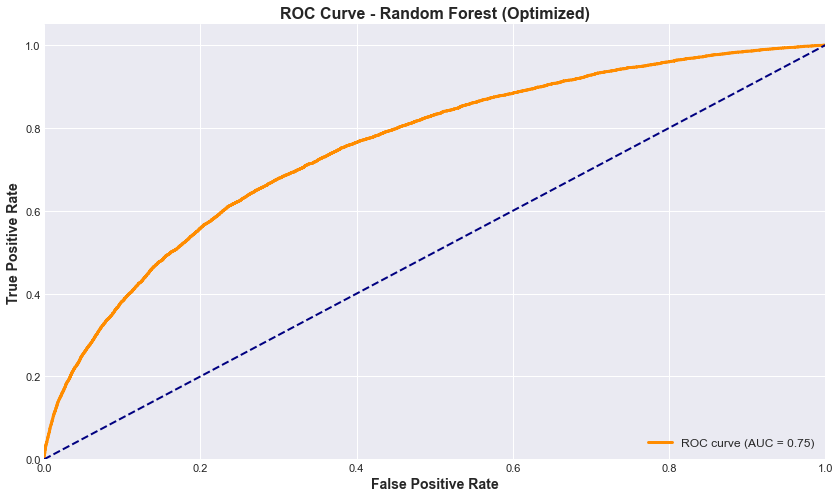

In [45]:
# 🔹 ROC Curve - Random Forest (Optimized)

# Compute ROC curve and AUC for the optimized Random Forest model
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_test_prob_rf)
roc_auc_rf = roc_auc_score(y_test, y_test_prob_rf)

# Display AUC
print(f"AUC Score: {roc_auc_rf:.2f}")

# Plot ROC Curve
plt.figure(figsize=(14,8))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=14, fontweight='bold')
plt.title('ROC Curve - Random Forest (Optimized)', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True)

# plt.savefig("Images/randomforest_roc.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

- ###  ***Contexte Business***

> Sur le plan stratégique, cette performance ROC suggère que le modèle peut être utilisé comme **outil de priorisation du risque** dans les processus de crédit.  
Dans un **marché haïtien caractérisé par une forte incertitude économique**, un tel outil aiderait les institutions financières à **mieux cibler les emprunteurs à surveiller** et à **optimiser leurs décisions d’octroi**.  
Ce modèle constitue donc une **base solide pour la modernisation du scoring de crédit**, et pourrait évoluer vers un système automatisé de **prévision du risque de défaut** au sein des banques haïtiennes.

## **Remarks and Models comparason**

Après avoir construit et évalué nos modèles principaux , **Régression Logistique Optimisée** et **Random Forest Optimisé** , nous pouvons comparer leurs performances et comprendre leurs rôles spécifiques dans la prédiction du risque de défaut.

| Modèle | Accuracy | Precision | Recall | F1-score | AUC |
|:-------|:---------:|:----------:|:--------:|:----------:|:----:|
| Régression Logistique Optimisée (identique à la baseline) | 0.69 | 0.23 | 0.70 | 0.34 | 0.76 |
| Random Forest Optimisé | 0.73 | 0.25 | 0.63 | 0.35 | 0.75 |

- Le **Random Forest Optimisé** présente la meilleure précision globale et un équilibre correct entre rappel et F1-score. Il est particulièrement utile pour identifier les clients à risque et limiter les pertes potentielles dans le portefeuille de prêts d’une banque haïtienne.  
- La **Régression Logistique Optimisée** n’améliore pas la baseline (c’est exactement le même modèle), mais elle reste **interprétable et rapide à déployer**, idéale pour les environnements où la transparence des décisions est cruciale.
- Comme les performances sont proches, nous avons choisi de **sauvegarder les deux modèles** pour garantir la **reproductibilité et la flexibilité future**.  
  - **Régression Logistique :** `../Models/logit_optimized_20251023_1225.joblib` 
  - **Random Forest :** `../Models/rf_optimized_20251023_1225.joblib`  
- Cela permet à toute institution souhaitant reproduire nos analyses ou tester le modèle sur de nouvelles données de **choisir le modèle le plus adapté à leur contexte opérationnel**.

---

- ## **Model Saving**

Après avoir entraîné et évalué les deux modèles — **Régression Logistique optimisée** et **Random Forest optimisé** —, il est essentiel de les **sauvegarder** afin de pouvoir les réutiliser sans devoir relancer tout le processus de modélisation.

Les modèles ont été exportés au format **`.joblib`**, un format plus rapide et plus robuste que `.pkl`, particulièrement adapté aux modèles volumineux ou complexes.  
Ils sont enregistrés dans le dossier `Models/` sous les noms suivants :

**Modèle Logistic Regression Optimisé** : `../Models/logit_optimized_20251023_1225.joblib`  
**Modèle Random Forest Optimisé** : `../Models/rf_optimized_20251023_1225.joblib`  

Tous les modèles ont été sauvegardés avec succès dans le dossier `Models/`.  
Ces fichiers permettront de **recharger instantanément les modèles** pour de futures prédictions ou pour les connecter à un **tableau de bord interactif**.

> Cette approche facilite la **réutilisation**, la **traçabilité** et la **mise en production** des modèles dans un contexte financier réel.  
> Par exemple, une institution de microfinance à **Port-au-Prince** ou **Les Cayes** pourrait directement importer ces modèles pour **analyser de nouveaux dossiers de prêt** et estimer la probabilité de remboursement sans assistance technique.

---

In [48]:
# SAUVEGARDE DU MODÈLE FINAL - RANDOM FOREST
from joblib import dump
import os

# Dossier de sauvegarde
models_dir = "../Models"
os.makedirs(models_dir, exist_ok=True)

# Sauvegarde du modèle et du préprocesseur
dump(rf_random, os.path.join(models_dir, "model_final.joblib"))
dump(preprocessor, os.path.join(models_dir, "preprocessor_final.pkl"))

print("✅ Modèle et préprocesseur finaux sauvegardés : model_final.joblib & preprocessor_final.pkl")

✅ Modèle et préprocesseur finaux sauvegardés : model_final.joblib & preprocessor_final.pkl


## **Shorts Insights**

Ces résultats démontrent la capacité à **prédire le risque de défaut de remboursement** à partir des caractéristiques d’un emprunteur, ce qui a plusieurs implications concrètes pour le contexte haïtien :

- Une **banque ou institution financière en Haïti** peut utiliser ces modèles pour évaluer rapidement la probabilité de remboursement d’un nouveau client.  
- Le **Random Forest Optimisé** sera particulièrement utile pour les institutions qui veulent **minimiser le risque de défaut** et capturer les comportements complexes des emprunteurs.  
- La **Régression Logistique**, en raison de sa simplicité et de son interprétabilité, peut être déployée pour les analyses **préliminaires, reporting ou décisions rapides**.  

Ces modèles sauvegardés (`logit_optimized_20251023_1315.joblib` et `rf_optimized_20251023_1315.joblib`) sont prêts à être réutilisés pour de **nouvelles prédictions**, par exemple pour des candidats dans une agence bancaire de Port-au-Prince ou Jacmel, en prétraitant leurs données avec le même pipeline que celui utilisé pour `X_train_processed`.  
Les insights détaillés, recommandations stratégiques et analyses approfondies seront présentés dans **le prochain notebook** :  
> **`03_insights_recommendations.ipynb`**, où nous détaillerons les **patterns clés**, les **clients à risque prioritaire**, et les **actions concrètes pour les institutions financières haïtiennes**.


## **Conclusion of the Notebook**

Ce notebook marque l’**aboutissement de la phase de modélisation** de notre projet de prédiction du risque de défaut de paiement :

1. Nous avons construit et optimisé deux modèles supervisés :  
   - **Régression Logistique Optimisée** (baseline améliorée pour inclure la gestion des classes déséquilibrées)  
   - **Random Forest Optimisé**  
2. Nous avons évalué chaque modèle à l’aide de métriques business pertinentes : **accuracy, recall, precision, F1-score, AUC**, ainsi que des **matrices de confusion** et **courbes ROC**.  
3. Les modèles ont été **sauvegardés dans le dossier `Models/`** pour permettre une **réutilisation future et reproductibilité** :  `logit_optimized_20251023_1315.joblib`  & `rf_optimized_20251023_1315.joblib`.
Ces modèles fournissent une **base solide** pour des analyses plus avancées.

Dans le prochain notebook (**`03_insights_recommendations.ipynb`**), nous allons approfondir les **insights clés**, identifier les **clients prioritaires** et proposer des **recommandations concrètes** adaptées au marché haïtien du crédit.  

> _« La donnée devient un véritable outil stratégique lorsque les institutions financières peuvent l’exploiter pour prendre des décisions éclairées et réduire le risque de défaut. »_
